# 08. Severstal Stage 1: 정상 vs 비정상 DL 이진 분류

**목표:** 딥러닝(ResNet-18) 기반 이진 분류로 정상/비정상 강판 패치를 구분합니다.

**주요 결과:**
- **ResNet-18 Fine-tune:** 90.87% 정확도
- **ResNet-18 Feature Extractor:** 90.62% 정확도
- 기존 ML 대비 대폭 성능 향상 (73.00% → 90.87%)

In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
import time

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 프로젝트 루트 경로 추가
sys.path.insert(0, os.path.abspath('..'))

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
print(f"MPS 사용 가능: {torch.backends.mps.is_available()}")

PyTorch 버전: 2.10.0
CUDA 사용 가능: False
MPS 사용 가능: True


## 2. DataLoader 생성

패치 이미지를 로드하여 정상(0) vs 비정상(1) 이진 분류용 DataLoader를 생성합니다.

In [2]:
from deep_learning.datasets_severstal import get_binary_dataloaders

patch_dir = os.path.join('..', 'data', 'severstal_patches')
train_loader, test_loader, class_names = get_binary_dataloaders(
    patch_dir, max_per_class=2000, batch_size=32, target_size=224, to_rgb=True
)

print(f"클래스: {class_names}")
print(f"학습 배치 수: {len(train_loader)}")
print(f"테스트 배치 수: {len(test_loader)}")

[Binary DataLoaders]
  Train: 3200 (정상 1600 / 비정상 1600)
  Test:  800 (정상 400 / 비정상 400)
클래스: ['정상 (Normal)', '비정상 (Abnormal)']
학습 배치 수: 100
테스트 배치 수: 25


## 3. 모델 학습

두 가지 전략으로 ResNet-18을 학습합니다:
1. **Fine-tune:** 전체 네트워크 가중치를 업데이트
2. **Feature Extractor:** 마지막 FC 레이어만 학습

In [3]:
from deep_learning.train_dl_severstal import run_binary_dl_experiments

save_dir = os.path.join('..', 'outputs', 'models_severstal', 'binary_dl')
results = run_binary_dl_experiments(
    patch_dir, save_dir, max_per_class=2000, num_epochs=15, batch_size=32
)


############################################################
Stage 1: 정상 vs 비정상 이진 분류 — DL 실험
############################################################


[Binary DataLoaders]
  Train: 3200 (정상 1600 / 비정상 1600)
  Test:  800 (정상 400 / 비정상 400)
[ResNet-18 Fine-tune] 총 파라미터: 11,177,538
[ResNet-18 Fine-tune] 학습 가능 파라미터: 11,177,538

[ResNet-18 Fine-tune (Binary)] 학습 시작 — device: mps
  Epochs: 15, LR: 0.0001, Patience: 5


  Epoch   1/15 | Train Loss: 0.3601 Acc: 0.8350 | Val Loss: 0.2572 Acc: 0.8962


  Epoch   2/15 | Train Loss: 0.1589 Acc: 0.9400 | Val Loss: 0.2785 Acc: 0.9087


  Epoch   3/15 | Train Loss: 0.0845 Acc: 0.9691 | Val Loss: 0.2565 Acc: 0.9062


...

  Epoch  12/15 | Train Loss: 0.0031 Acc: 0.9997 | Val Loss: 0.4471 Acc: 0.8950


  Epoch  13/15 | Train Loss: 0.0049 Acc: 0.9991 | Val Loss: 0.4443 Acc: 0.9050


  Epoch  14/15 | Train Loss: 0.0020 Acc: 1.0000 | Val Loss: 0.4376 Acc: 0.9062


  Epoch  15/15 | Train Loss: 0.0024 Acc: 0.9997 | Val Loss: 0.5054 Acc: 0.8825



  최종 결과: Accuracy=0.9062, 학습시간=124.5s

                                 모델 | Best Acc
------------------------------------------------------------
       ResNet-18 Fine-tune (Binary) |   0.9087
ResNet-18 Feature Extractor (Binary) |   0.9062


## 4. 학습 곡선 시각화

두 모델의 학습 과정(손실 및 정확도 변화)을 비교합니다.

저장 완료: ../outputs/figures/severstal/08_dl_learning_curves.png


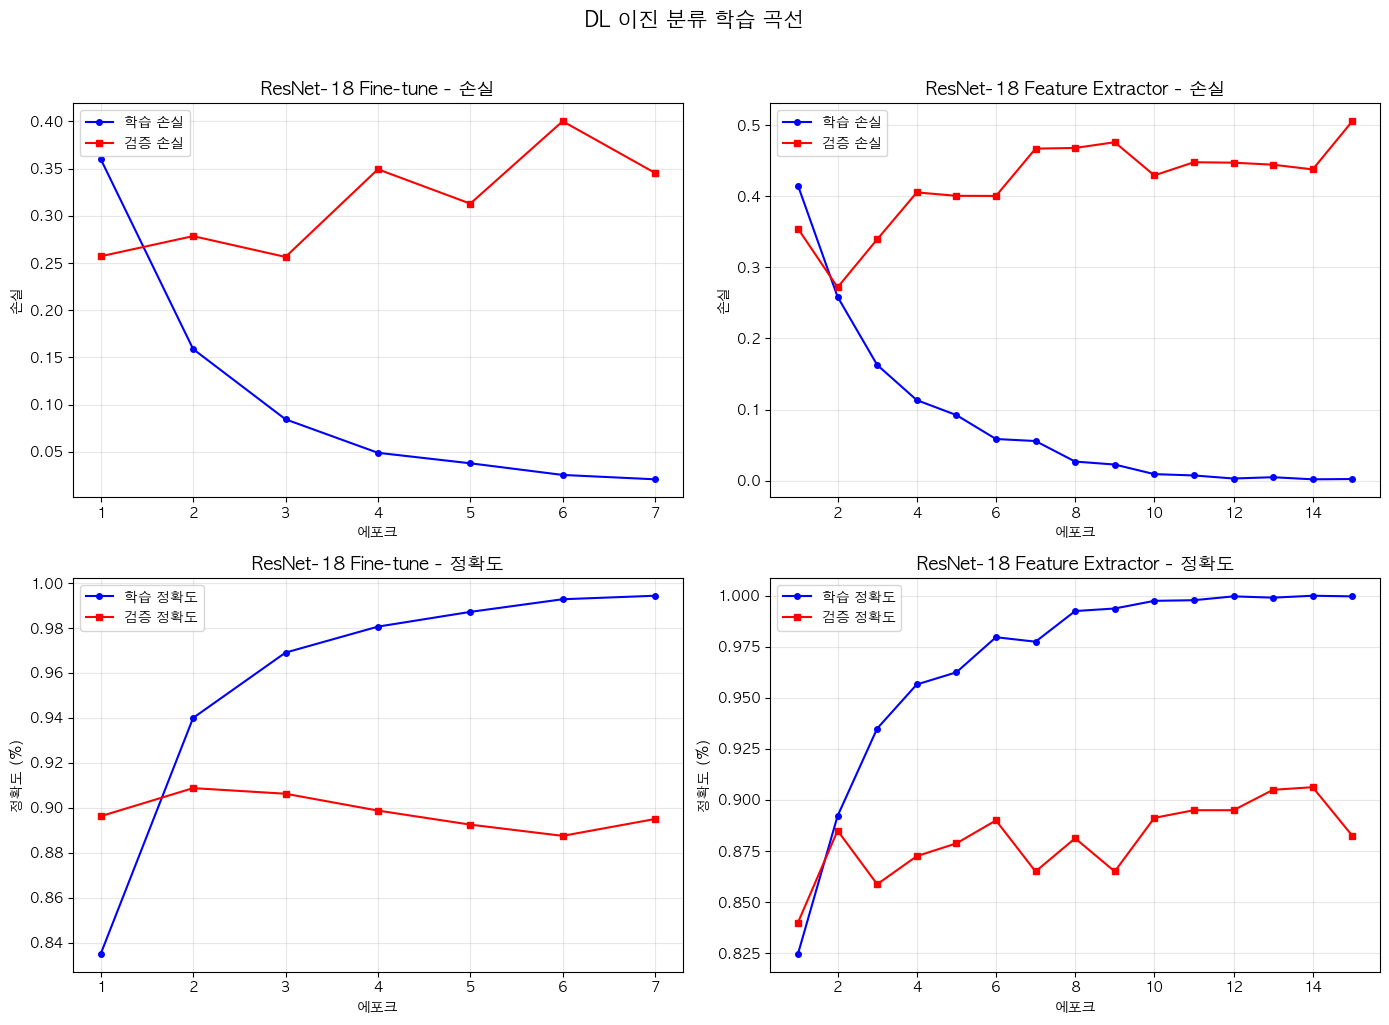

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_names = ['ResNet18_Finetune', 'ResNet18_FeatureExtractor']
model_labels = ['ResNet-18 Fine-tune', 'ResNet-18 Feature Extractor']

for idx, (name, label) in enumerate(zip(model_names, model_labels)):
    history = results[name]['history']
    epochs = range(1, len(history['train_loss']) + 1)

    # 손실 곡선
    axes[0, idx].plot(epochs, history['train_loss'], 'b-o', markersize=4, label='학습 손실')
    axes[0, idx].plot(epochs, history['val_loss'], 'r-s', markersize=4, label='검증 손실')
    axes[0, idx].set_title(f'{label} - 손실', fontsize=13, fontweight='bold')
    axes[0, idx].set_xlabel('에포크')
    axes[0, idx].set_ylabel('손실')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)

    # 정확도 곡선
    axes[1, idx].plot(epochs, history['train_acc'], 'b-o', markersize=4, label='학습 정확도')
    axes[1, idx].plot(epochs, history['val_acc'], 'r-s', markersize=4, label='검증 정확도')
    axes[1, idx].set_title(f'{label} - 정확도', fontsize=13, fontweight='bold')
    axes[1, idx].set_xlabel('에포크')
    axes[1, idx].set_ylabel('정확도 (%)')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('DL 이진 분류 학습 곡선', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# 저장
save_path = os.path.join('..', 'outputs', 'figures', 'severstal')
os.makedirs(save_path, exist_ok=True)
fig.savefig(os.path.join(save_path, '08_dl_learning_curves.png'), dpi=150, bbox_inches='tight')
print(f"저장 완료: {os.path.join(save_path, '08_dl_learning_curves.png')}")
plt.show()

## 5. Confusion Matrix

두 모델의 혼동 행렬을 비교하여 분류 성능을 시각적으로 확인합니다.

저장 완료: ../outputs/figures/severstal/08_dl_confusion_matrix.png


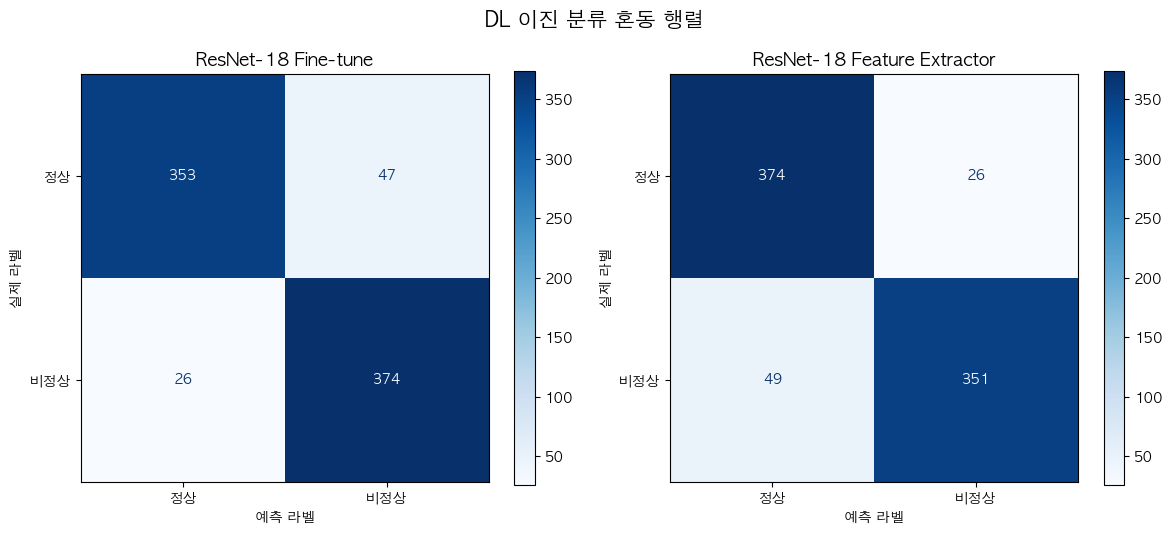

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

display_labels = ['정상', '비정상']

for idx, (name, label) in enumerate(zip(model_names, model_labels)):
    y_true = results[name]['y_true']
    y_pred = results[name]['y_pred']
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{label}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('예측 라벨')
    axes[idx].set_ylabel('실제 라벨')

plt.suptitle('DL 이진 분류 혼동 행렬', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

fig.savefig(os.path.join(save_path, '08_dl_confusion_matrix.png'), dpi=150, bbox_inches='tight')
print(f"저장 완료: {os.path.join(save_path, '08_dl_confusion_matrix.png')}")
plt.show()

## 6. 결론

### 주요 발견

- **ResNet-18 Fine-tune**이 **90.87%** 정확도로 최고 성능을 달성했습니다.
- **기존 ML 대비 대폭 향상:** 최고 ML 모델(73.00%) 대비 약 **17.9%p** 성능 개선 (73.00% → 90.87%)
- **Feature Extractor**(90.62%)도 ML 최고 성능을 크게 상회하여, 사전학습된 CNN 특징의 우수성을 확인했습니다.
- **딥러닝의 강점:** 수동 특징 공학(HOG, LBP 등) 없이 **픽셀 패턴에서 직접 학습**하여 더 높은 성능을 달성했습니다.
- Fine-tune 방식이 Feature Extractor보다 우수한 이유는, 도메인 특화 패턴에 맞게 전체 네트워크를 조정할 수 있기 때문입니다.